# Previsão de Óbito por Tuberculose em Idosos no Sudeste

Neste projeto, vou construir e comparar 3 modelos de machine learning capaz de prever se um paciente idoso na região Sudeste corre um risco maior de ir a óbito por tuberculose. 

Para isso, decidi juntar tudo em um único arquivo: desde a leitura da base de dados bruta, passando por todo o tratamento passo a passo, até a etapa final de modelagem preditiva.


## 1. Configuração e Bibliotecas

Primeiro, vou garantir que tenho tudo instalado e vou importar as bibliotecas que vou usar ao longo de toda a minha análise.

> Nota: Se estiver executando localmente com ambiente virtual (venv) ativado e dependências instaladas via requirements.txt, pode pular a célula de instalação abaixo. No Google Colab, execute a célula para instalar as bibliotecas na sessão.

In [1]:
!pip install xgboost plotly scikit-learn seaborn matplotlib pandas numpy nbformat shap kaleido -q



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualizações
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Configura o renderizador do Plotly para gerar PNG estatico (compativel com visualizacao no GitHub)
pio.renderers.default = "png"

# Utilidades
from copy import deepcopy

# Sklearn (Machine Learning e Pré-Processamento)
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

# Configurando uma semente para garantir que meus resultados sejam reproduzíveis
seed = 42


## 2. Leitura e Visualização Inicial dos Dados Brutos

Agora vou carregar a base de dados original de tuberculose que pegamos do sistema do governo e ver a cara dela.


### 2.0 Origem e Contexto dos Dados (SINAN / DATASUS / Ministério da Saúde)

A base de dados e os preceitos metodológicos deste estudo são originários do curso oficial de capacitação técnica:

* **Curso:** *Introdução à Inteligência Artificial para Predições em Vigilância em Saúde e Ambiente*
* **Realização:** **Ministério da Saúde do Brasil** — Secretaria de Vigilância em Saúde e Ambiente (**SVSA**)
* **Coordenação Técnica:** Departamento de Ações Estratégicas de Epidemiologia e Vigilância em Saúde e Ambiente (**Daevs**) / Coordenação-Geral de Desenvolvimento da Epidemiologia em Serviços (**CGDEP**)
* **Parceria Acadêmica:** **Universidade de São Paulo (USP)** — **Laboratório de Big Data e Análise Preditiva em Saúde (Labdaps/USP)**
* **Coordenação Docente:** Prof. Dr. Alexandre Dias Porto Chiavegatto Filho e equipe de pesquisadores do Labdaps/USP.

#### Fonte Primária dos Microdados
Os dados brutos (`dados_tuberculose.csv`) representam registros oficiais de **notificações compulsórias de Tuberculose** consolidadas no **SINAN (Sistema de Informação de Agravos de Notificação)** e disponibilizadas pelo **DATASUS**. A base consolidada de 250 MB está disponível publicamente no [Kaggle Datasets](https://www.kaggle.com/datasets/caulourenovalotto/sinan-microdados-de-tuberculose-datasus). 

#### Recorte Epidemiológico Aplicado:
1. **Filtro Geográfico:** Região Sudeste (SP, RJ, MG, ES) — estados com códigos UF `[35, 33, 31, 32]`;
2. **Filtro Etário:** População idosa com idade igual ou superior a **60 anos** ($\ge 60$ anos), grupo prioritário de maior vulnerabilidade clínica e letalidade;
3. **Filtro Temporal:** Notificações a partir do ano de **2022**;
4. **Tratamento de Vazamento Retrospectivo (*Data Leakage*):** Exclusão de casos que ingressaram como `TRATAMENTO = 6` ("Pós-Óbito"), pois são fichas abertas após o óbito (SVO/IML) que enviesariam o modelo preditivo prospectivo;
5. **Desfecho Binário Supervisionado:** Casos com encerramento (`SITUA_ENCE`) definido em **Não Óbito (Cura, código 1 → 0)** ou **Óbito por Tuberculose (código 3 → 1)**.

In [3]:
import os

# Caminho para os dados brutos
path_dados_brutos = "data/dados_tuberculose.csv"

if os.path.exists(path_dados_brutos):
    # Importando os dados do csv
    df = pd.read_csv(path_dados_brutos, encoding="latin1", sep=",")
    print("Data Frame original:", df.shape)
else:
    print("Aviso: Arquivo bruto 'dados_tuberculose.csv' (250 MB) não encontrado localmente.")
    print("Para baixar a base bruta oficial, acesse o Kaggle Datasets:")
    print("https://www.kaggle.com/datasets/caulourenovalotto/sinan-microdados-de-tuberculose-datasus")
    print("\nPara prosseguir com os dados pré-processados já disponíveis na pasta data/, pule para a Seção 4.")


C:\Users\Admin\AppData\Local\Temp\ipykernel_18284\3205032085.py:8: DtypeWarning: Columns (0: DT_DIGITA, 1: DT_TRANSUS, 2: EXTRAPU1_N, 3: EXTRAPUL_O, 4: AGRAVOUTDE, 5: BACILOS_E2, 6: ETIONAMIDA, 7: OUTRAS_DES, 8: DT_NOTI_AT, 9: DT_MUDANCA, 10: MUN_TRANSF) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path_dados_brutos, encoding="latin1", sep=",")


Data Frame original: (772270, 98)


In [4]:
# Olhando quais são as colunas que o arquivo possui
df.columns


Index(['TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO', 'SG_UF_NOT',
       'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC', 'NU_IDADE_N',
       'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF', 'ID_MN_RESI',
       'ID_RG_RESI', 'ID_PAIS', 'NDUPLIC_N', 'IN_VINCULA', 'DT_DIGITA',
       'DT_TRANSUS', 'DT_TRANSDM', 'DT_TRANSSM', 'DT_TRANSRM', 'DT_TRANSRS',
       'DT_TRANSSE', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W', 'ID_OCUPA_N',
       'TRATAMENTO', 'INSTITUCIO', 'RAIOX_TORA', 'TESTE_TUBE', 'FORMA',
       'EXTRAPU1_N', 'EXTRAPU2_N', 'EXTRAPUL_O', 'AGRAVAIDS', 'AGRAVALCOO',
       'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'AGRAVOUTDE', 'BACILOSC_E',
       'BACILOS_E2', 'BACILOSC_O', 'CULTURA_ES', 'CULTURA_OU', 'HIV',
       'HISTOPATOL', 'DT_INIC_TR', 'RIFAMPICIN', 'ISONIAZIDA', 'ETAMBUTOL',
       'ESTREPTOMI', 'PIRAZINAMI', 'ETIONAMIDA', 'OUTRAS', 'OUTRAS_DES',
       'TRAT_SUPER', 'NU_CONTATO', 'DOENCA_TRA', 'SG_UF_AT', 'ID_MUNIC_A',
       'DT_NOTI_AT', 'SG_UF_2', 'ID_MUN

In [5]:
# Dando uma olhada nas primeiras 5 linhas para entender o formato dos dados
df.head()


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,NU_IDADE_N,...,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,IDADE_ANOS
0,2,A169,2016-03-30,2016,26,261160.0,1497.0,2013-06-17,1976.0,4037.0,...,9.0,9.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,37.0
1,2,A169,2017-04-07,2017,23,230190.0,1531.0,2013-09-11,1970.0,4042.0,...,0.0,0.0,5.0,7.0,0.0,0.0,0.0,NaN,NaN,42.0
2,2,A169,2016-05-02,2016,33,330600.0,0.0,2013-10-15,1964.0,4049.0,...,2.0,2.0,5.0,0.0,0.0,0.0,0.0,NaN,NaN,49.0
3,2,A169,2017-06-30,2017,42,420540.0,1476.0,2013-07-30,1962.0,4050.0,...,2.0,1.0,5.0,0.0,2.0,4.0,1.0,NaN,NaN,50.0
4,2,A169,2016-03-22,2016,23,230765.0,1513.0,2013-07-15,1955.0,4058.0,...,2.0,1.0,5.0,5.0,0.0,2.0,2.0,23.0,23.0,58.0


### Dicionário de Variáveis do SINAN

O arquivo original `dados_tuberculose.csv` possui **98 colunas**, correspondendo a todos os campos oficiais da ficha de notificação e acompanhamento de Tuberculose do SINAN/DATASUS.

Para manter este notebook conciso e focado na análise e modelagem, a descrição detalhada e o significado de cada uma das 98 variáveis foram organizados em um arquivo dedicado: [dicionario_variaveis.md](dicionario_variaveis.md).

### 2.1 Aplicando os Filtros de Escopo (Incluindo Casos de Pós-Óbito)

Eu quero focar o meu modelo na **região Sudeste**, em **pessoas com 60 anos ou mais**, e usando apenas notificações a partir do ano de **2022**. Nesta versão da análise, optamos por **manter os casos de Pós-Óbito (`TRATAMENTO == 6`)**, permitindo avaliar o comportamento dos algoritmos com a totalidade dos registros da coorte e o forte sinal prognóstico emitido por essa notificação.


In [6]:
# Filtra os estados da região Sudeste (MG=31, ES=32, RJ=33, SP=35)
sudeste = [31, 32, 33, 35]
df = df.loc[df['SG_UF'].isin(sudeste)]

# Filtro de pessoas da terceira idade
df = df.loc[(df.IDADE_ANOS >= 60)]

# Filtro para ano maior ou igual a 2022
df = df.loc[df["NU_ANO"] >= 2022]

# Casos com TRATAMENTO == 6 (Pós-óbito) mantidos na base
# df = df.loc[df['TRATAMENTO'] != 6]

# Vamos ver quantas linhas sobraram
print("DataFrame após filtros:", df.shape)


DataFrame após filtros: (13999, 98)


### 2.2 Criação da Variável de Desfecho (Target)

Meu objetivo é prever Óbito. Então vou descartar desfechos incertos (como abandono ou transferência) e manter apenas **Não Óbito (1)** e **Óbito por Tuberculose (3)**. Depois, vou transformar isso em 0 (Não Óbito) e 1 (Óbito) para facilitar a vida do modelo.


In [7]:
# Mantém apenas Não Óbito e Óbito
df = df.loc[df["SITUA_ENCE"].isin([1, 3])]

# Dicionário que substitui os valores
dict_desfecho = {3: 1, 1: 0}
df['SITUA_ENCE'] = df['SITUA_ENCE'].replace(dict_desfecho)

# Alteração do nome da coluna para ficar mais óbvio
df.rename(columns={'SITUA_ENCE': "OBITO"}, inplace=True)

print("Tamanho final do DataFrame com desfechos válidos:", df.shape)


Tamanho final do DataFrame com desfechos válidos: (9722, 98)


### 2.3 Seleção das Variáveis (Features)

Para não confundir meu modelo com colunas que não importam (como números de formulário ou dados de controle), vou selecionar as variáveis clínicas e demográficas essenciais para o prognóstico.

In [8]:
# Variaveis independentes
lista_variaveis_categoricas = [
    'SG_UF', 'CS_SEXO', 'CS_RACA', 'CS_ESCOL_N',
    'TRATSUP_AT', 'TRATAMENTO', 'AGRAVDROGA',
    'POP_RUA', 'POP_LIBER', 'BACILOSC_E',
    'AGRAVALCOO', 'FORMA', 'CS_GESTANT', 'AGRAVTABAC',
    'AGRAVDIABE', 'HIV', 'RAIOX_TORA'
]
lista_variaveis_numericas = ['IDADE_ANOS']

# Variavel Desfecho
variavel_desfecho = ['OBITO']

# Novo DataFrame apenas com as colunas selecionadas
df = df[lista_variaveis_categoricas + lista_variaveis_numericas + variavel_desfecho]

# Alteração do tipo do dado para nominal e numérico
df[lista_variaveis_categoricas] = df[lista_variaveis_categoricas].astype(object)
df["IDADE_ANOS"] = df["IDADE_ANOS"].astype(float)

# Colocando os nomes das colunas em minúsculas 
df.columns = df.columns.str.lower()
lista_variaveis_categoricas = [c.lower() for c in lista_variaveis_categoricas]
lista_variaveis_numericas = [c.lower() for c in lista_variaveis_numericas]

# Vamos verificar as informações finais dessa nossa tabela
df.info()


<class 'pandas.DataFrame'>
Index: 9722 entries, 275888 to 772260
Data columns (total 19 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sg_uf       9722 non-null   object 
 1   cs_sexo     9722 non-null   object 
 2   cs_raca     8465 non-null   object 
 3   cs_escol_n  8871 non-null   object 
 4   tratsup_at  8954 non-null   object 
 5   tratamento  9722 non-null   object 
 6   agravdroga  9610 non-null   object 
 7   pop_rua     9610 non-null   object 
 8   pop_liber   9615 non-null   object 
 9   bacilosc_e  9722 non-null   object 
 10  agravalcoo  9639 non-null   object 
 11  forma       9722 non-null   object 
 12  cs_gestant  9456 non-null   object 
 13  agravtabac  9617 non-null   object 
 14  agravdiabe  9631 non-null   object 
 15  hiv         9663 non-null   object 
 16  raiox_tora  9645 non-null   object 
 17  idade_anos  9722 non-null   float64
 18  obito       9722 non-null   float64
dtypes: float64(2), object(17)
memory usa

## 3. Preparando os Dados para o Modelo (Pré-Processamento)

Aqui eu defino uma função simples para visualizar o DataFrame ao longo das etapas.


In [9]:
def visualizar_dataframe(df_temp, nome_df):
    """Função que dá o shape do dataframe e fornece as 5 primeiras linhas"""
    print(f"Shape {nome_df}: ", df_temp.shape)
    display(df_temp.head())


### 3.1 Separação Treino e Teste

Vou dividir minha base em dados que o modelo vai usar para **aprender** (Treino) e dados que eu vou esconder do modelo para usarmos depois como **prova final** (Teste).


In [10]:
# Separação da base entre variáveis preditoras (X) e nosso alvo (y)
X = df.drop(columns="obito")
y = df.obito.copy()

# Separação entre treino (75%) e teste (25%), mantendo a mesma proporção de óbitos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=seed)


In [11]:
# Visualizar dataframe de treino e teste
visualizar_dataframe(X_train, "X_train")
visualizar_dataframe(X_test, "X_test")


Shape X_train:  (7291, 18)


,sg_uf,cs_sexo,cs_raca,cs_escol_n,tratsup_at,tratamento,agravdroga,pop_rua,pop_liber,bacilosc_e,agravalcoo,forma,cs_gestant,agravtabac,agravdiabe,hiv,raiox_tora,idade_anos
587047,31,M,4.0,2.0,2.0,5,2.0,2.0,2.0,3.0,2.0,1.0,6.0,1.0,1.0,4.0,2.0,83.0
649019,33,F,4.0,3.0,2.0,1,2.0,2.0,2.0,3.0,2.0,1.0,5.0,2.0,2.0,2.0,4.0,83.0
715202,35,F,2.0,3.0,2.0,1,2.0,2.0,2.0,3.0,2.0,1.0,5.0,2.0,2.0,2.0,4.0,69.0
712749,33,F,1.0,1.0,2.0,2,2.0,2.0,2.0,2.0,2.0,1.0,5.0,2.0,2.0,2.0,1.0,67.0
721502,35,F,1.0,1.0,9.0,1,2.0,2.0,2.0,2.0,2.0,2.0,5.0,2.0,1.0,2.0,4.0,88.0


Shape X_test:  (2431, 18)


,sg_uf,cs_sexo,cs_raca,cs_escol_n,tratsup_at,tratamento,agravdroga,pop_rua,pop_liber,bacilosc_e,agravalcoo,forma,cs_gestant,agravtabac,agravdiabe,hiv,raiox_tora,idade_anos
613555,33,F,1.0,8.0,2.0,1,2.0,2.0,2.0,2.0,2.0,1.0,5.0,2.0,2.0,4.0,2.0,74.0
607291,33,M,9.0,2.0,1.0,1,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,2.0,1.0,71.0
655537,33,M,4.0,2.0,2.0,2,2.0,2.0,2.0,3.0,2.0,1.0,6.0,1.0,2.0,2.0,1.0,71.0
657287,33,F,2.0,3.0,1.0,1,2.0,2.0,2.0,3.0,2.0,2.0,6.0,2.0,2.0,2.0,1.0,69.0
654489,35,M,1.0,3.0,1.0,1,2.0,2.0,2.0,2.0,2.0,1.0,6.0,2.0,2.0,2.0,2.0,72.0


In [12]:
visualizar_dataframe(y_train, "y_train")
visualizar_dataframe(y_test, "y_test")


Shape y_train:  (7291,)


587047    0.0
649019    0.0
715202    0.0
712749    0.0
721502    1.0
Name: obito, dtype: float64

Shape y_test:  (2431,)


613555    0.0
607291    0.0
655537    0.0
657287    0.0
654489    0.0
Name: obito, dtype: float64

In [13]:
# Verificação da proporção de óbitos na base de treino e teste
display(y_train.value_counts(normalize=True))
display(y_test.value_counts(normalize=True))


obito
0.0    0.843917
1.0    0.156083
Name: proportion, dtype: float64

obito
0.0    0.843686
1.0    0.156314
Name: proportion, dtype: float64

### 3.2 Tratamento de Valores Ausentes (Missings)

Na vida real, a base de dados vem cheia de "buracos" (valores nulos). Os modelos não conseguem rodar com isso, então vou preenchê-los.
Para a variável numérica (idade), vou usar a média calculada no treino. Já para as variáveis categóricas, como ensinado na aula, vou criar a categoria "variavel_ausente", preservando a informação da ausência de dado em vez de usar a moda.


In [14]:
# Quantidade de valores nulos antes do tratamento
print("Missings no Treino antes: ", X_train.isna().sum().sum())
print("Missings no Teste antes: ", X_test.isna().sum().sum())


Missings no Treino antes:  2969
Missings no Teste antes:  919


In [15]:
# Calculando os padrões no treino
medias_treino = X_train[lista_variaveis_numericas].mean()

# Aplicação das médias na base de treino e de teste
X_train[lista_variaveis_numericas] = X_train[lista_variaveis_numericas].fillna(medias_treino)
X_test[lista_variaveis_numericas] = X_test[lista_variaveis_numericas].fillna(medias_treino)

# Criando a categoria 'variavel_ausente' nas variáveis categóricas
X_train[lista_variaveis_categoricas] = X_train[lista_variaveis_categoricas].fillna("variavel_ausente").astype(str)
X_test[lista_variaveis_categoricas] = X_test[lista_variaveis_categoricas].fillna("variavel_ausente").astype(str)

# Quantidade de valores nulos DEPOIS do tratamento
print("Missings no Treino depois: ", X_train.isna().sum().sum())
print("Missings no Teste depois: ", X_test.isna().sum().sum())


Missings no Treino depois:  0
Missings no Teste depois:  0


### 3.3 Padronização (Idade)

Para não causar problemas matemáticos em alguns modelos, vou normalizar a variável idade para ter média 0 e desvio padrão 1.


In [16]:
# Criação do Scaler
scaler = StandardScaler()

# Treino do Scaler na base de treino
scaler.fit(X_train[lista_variaveis_numericas])

# Aplicação do Scaler na base de treino e de teste
X_train[lista_variaveis_numericas] = scaler.transform(X_train[lista_variaveis_numericas])
X_test[lista_variaveis_numericas] = scaler.transform(X_test[lista_variaveis_numericas])

# Vamos ver a distribuição padronizada (treino)
X_train.describe().round(2)


,idade_anos
count,7291.00
mean,-0.00
std,1.00
min,-1.18
25%,-0.77
50%,-0.23
75%,0.59
max,5.48


In [17]:
# Vamos ver a distribuição padronizada (teste)
X_test.describe().round(2)


,idade_anos
count,2431.00
mean,0.01
std,0.98
min,-1.18
25%,-0.77
50%,-0.23
75%,0.59
max,3.72


In [18]:
visualizar_dataframe(X_train, "X_train")
visualizar_dataframe(X_test, "X_test")


Shape X_train:  (7291, 18)


,sg_uf,cs_sexo,cs_raca,cs_escol_n,tratsup_at,tratamento,agravdroga,pop_rua,pop_liber,bacilosc_e,agravalcoo,forma,cs_gestant,agravtabac,agravdiabe,hiv,raiox_tora,idade_anos
587047,31,M,4.0,2.0,2.0,5,2.0,2.0,2.0,3.0,2.0,1.0,6.0,1.0,1.0,4.0,2.0,1.946533
649019,33,F,4.0,3.0,2.0,1,2.0,2.0,2.0,3.0,2.0,1.0,5.0,2.0,2.0,2.0,4.0,1.946533
715202,35,F,2.0,3.0,2.0,1,2.0,2.0,2.0,3.0,2.0,1.0,5.0,2.0,2.0,2.0,4.0,0.041927
712749,33,F,1.0,1.0,2.0,2,2.0,2.0,2.0,2.0,2.0,1.0,5.0,2.0,2.0,2.0,1.0,-0.230160
721502,35,F,1.0,1.0,9.0,1,2.0,2.0,2.0,2.0,2.0,2.0,5.0,2.0,1.0,2.0,4.0,2.626749


Shape X_test:  (2431, 18)


,sg_uf,cs_sexo,cs_raca,cs_escol_n,tratsup_at,tratamento,agravdroga,pop_rua,pop_liber,bacilosc_e,agravalcoo,forma,cs_gestant,agravtabac,agravdiabe,hiv,raiox_tora,idade_anos
613555,33,F,1.0,8.0,2.0,1,2.0,2.0,2.0,2.0,2.0,1.0,5.0,2.0,2.0,4.0,2.0,0.722143
607291,33,M,9.0,2.0,1.0,1,2.0,2.0,2.0,1.0,2.0,1.0,6.0,2.0,2.0,2.0,1.0,0.314014
655537,33,M,4.0,2.0,2.0,2,2.0,2.0,2.0,3.0,2.0,1.0,6.0,1.0,2.0,2.0,1.0,0.314014
657287,33,F,2.0,3.0,1.0,1,2.0,2.0,2.0,3.0,2.0,2.0,6.0,2.0,2.0,2.0,1.0,0.041927
654489,35,M,1.0,3.0,1.0,1,2.0,2.0,2.0,2.0,2.0,1.0,6.0,2.0,2.0,2.0,2.0,0.450057


### 3.4 Transformação das Categóricas (One-Hot Encoding)

Os algoritmos não entendem texto ("Branco", "Feminino"), então vou usar o One-Hot Encoder para criar colunas de 0 e 1 para cada categoria possível.


In [19]:
# Cria o One-Hot Encoder
encoder = OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[lista_variaveis_categoricas])

# Transforma e recria o DataFrame
X_train_enc = pd.DataFrame(encoder.transform(X_train[lista_variaveis_categoricas]), columns=encoder.get_feature_names_out(), index=X_train.index)
X_test_enc = pd.DataFrame(encoder.transform(X_test[lista_variaveis_categoricas]), columns=encoder.get_feature_names_out(), index=X_test.index)

# Joga fora as colunas velhas e junta as numéricas com as novas codificadas
X_train = pd.concat([X_train.drop(columns=lista_variaveis_categoricas), X_train_enc], axis=1)
X_test = pd.concat([X_test.drop(columns=lista_variaveis_categoricas), X_test_enc], axis=1)

visualizar_dataframe(X_train, "X_train (Final Pronto pro Modelo)")


Shape X_train (Final Pronto pro Modelo):  (7291, 86)


,idade_anos,sg_uf_31,sg_uf_32,sg_uf_33,sg_uf_35,cs_sexo_F,cs_sexo_I,cs_sexo_M,cs_raca_1.0,cs_raca_2.0,...,hiv_1.0,hiv_2.0,hiv_3.0,hiv_4.0,hiv_variavel_ausente,raiox_tora_1.0,raiox_tora_2.0,raiox_tora_3.0,raiox_tora_4.0,raiox_tora_variavel_ausente
587047,1.946533,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
649019,1.946533,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
715202,0.041927,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
712749,-0.230160,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
721502,2.626749,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 3.5 Salvando o DataFrame

→ Por fim, unimos as variáveis preditoras com a variável alvo em dataframes completos para treino e teste, e salvamos esses conjuntos em arquivos CSV, facilitando o uso futuro e a reprodutibilidade dos experimentos (seguindo o padrão do tópico 8 da aula de pré-processamento).


In [20]:
# Unificando base de Treino
df_train = pd.concat([X_train, y_train], axis=1)

# Salvando base de Treino
path_to_save_train = "data/dados_treino_preprocessado.csv"
df_train.to_csv(path_to_save_train, index=False)


In [21]:
# Unificando base de Teste
df_test = pd.concat([X_test, y_test], axis=1)

# Salvando base de Teste
path_to_save_test = "data/dados_teste_preprocessado.csv"
df_test.to_csv(path_to_save_test, index=False)


## 4. O Treinamento dos Modelos de Machine Learning

Agora que eu terminei a fase pesada de dados, vou treinar três algoritmos diferentes. Em vez de simplesmente instanciar o modelo, eu vou usar ferramentas de busca (`GridSearchCV` e `RandomizedSearchCV`) para testar várias combinações de parâmetros e achar a melhor versão de cada um deles.


### 4.1 Modelo 1: Regressão Logística
É o modelo mais clássico e simples.


In [22]:
# modelo e dicionário de busca
lr = LogisticRegression(max_iter=1000, random_state=seed)
lr_dict = {
    'C': np.logspace(-3, 3, 10),              # força da regularização (quanto menor o valor, mais forte a regularização)
}

# criação do grid search
lr_gs = GridSearchCV(estimator=lr,          # modelo
                      param_grid=lr_dict,   # dicionário com a lista dos hiperparâmetros
                      scoring='roc_auc',    # métrica de avaliação
                      cv=5,                 # validação cruzada 5-fold
                      n_jobs=1              # execução estável
                      )

# fit do grid search
lr_gs.fit(X_train, y_train)

# print dos melhores hiperparametros
print("Hiperparametros do lr: ", lr_gs.best_params_)

# criação do modelo final
lr_best = lr_gs.best_estimator_


Hiperparametros do lr:  {'C': np.float64(0.1)}


### 4.2 Modelo 2: Random Forest
Um algoritmo de "floresta aleatória" que cria várias árvores de decisão.


In [23]:
# Modelo e dicionário de busca
rf = RandomForestClassifier(random_state=seed, n_jobs=-1)
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 200 a 500 com passo de 100
    'max_depth': np.arange(5, 15, 1),                   # profundidade máxima, de 5 a 14
    'min_samples_split': np.geomspace(0.005, 0.05, 5),  # fração mínima de amostras para dividir um nó (escala geométrica)
    'min_samples_leaf': [5, 15, 25],                    # número mínimo de amostras em cada folha
    'max_features': ['sqrt', 'log2', None],             # número máximo de features consideradas por divisão
}

# Criação do random search
rf_rs = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_dict,
    n_iter=20,              # número de combinações testadas
    scoring='roc_auc',      # métrica de avaliação
    cv=5,                   # validação cruzada 5-fold
    random_state=seed,      # seed para garantir reprodutibilidade
    n_jobs=1                # busca sequencial com RF paralelizado internamente
)

# Fit do random search
rf_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparâmetros do rf: ", rf_rs.best_params_)

# Criação do modelo final
rf_best = rf_rs.best_estimator_


Hiperparâmetros do rf:  {'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.005), 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': np.int64(10)}


### 4.3 Modelo 3: XGBoost
Considerado um dos modelos mais fortes da atualidade para dados tabulares. Ele constrói árvores sequencialmente, uma focando nos erros da anterior.


In [24]:
# Modelo e dicionário de busca
xgb = XGBClassifier(
    objective='binary:logistic',  # problema de classificação binária
    eval_metric='logloss',
    random_state=seed,
    n_jobs=-1
)

xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# Criação do random search
xgb_rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_dict,
    n_iter=20,              # número de combinações testadas
    scoring='roc_auc',      # métrica de avaliação
    cv=5,                   # validação cruzada 5-fold
    random_state=seed,      # seed para garantir reprodutibilidade
    n_jobs=1                # busca sequencial com XGBoost paralelizado internamente
)

# Fit do random search
xgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparâmetros do xgb: ", xgb_rs.best_params_)

# Criação do modelo final
xgb_best = xgb_rs.best_estimator_


Hiperparâmetros do xgb:  {'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


## 5. Avaliação dos Modelos e Comparação Visual

Com os 3 treinados, vou pedir para eles preverem o resultado na nossa base de TESTE, e vou plotar os gráficos de performance para ver quem foi melhor.


In [25]:
# Calculando a probabilidade prevista (de óbito) para cada modelo
y_prob_lr = lr_best.predict_proba(X_test)[:, 1]
y_prob_rf = rf_best.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb_best.predict_proba(X_test)[:, 1]


### 5.1 Curva ROC
Essa curva mostra a relação entre o meu acerto de óbitos reais e os "alarmes falsos" que o modelo gera. Quanto maior a área abaixo da curva (AUC), melhor.


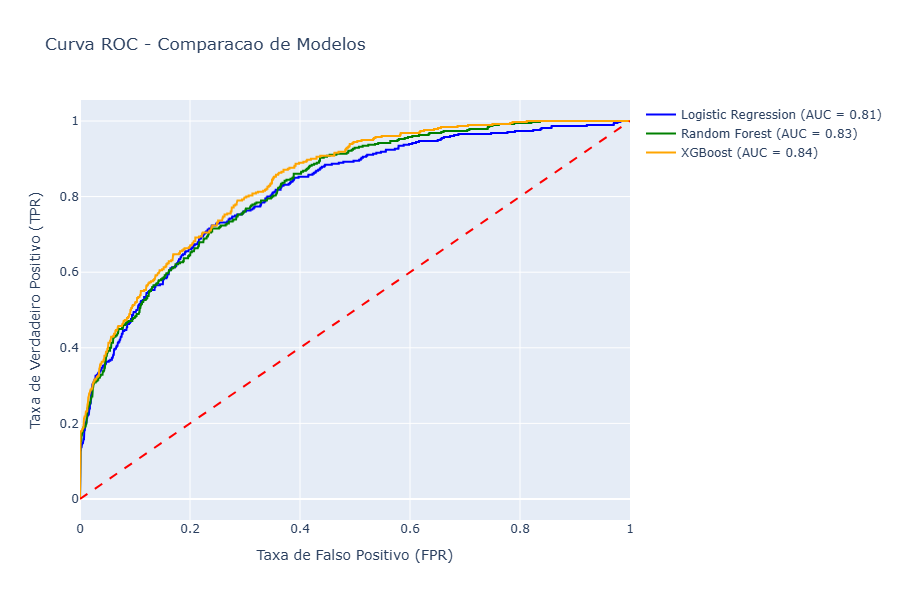

In [26]:
# Calcula as curvas ROC e AUC para cada modelo
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Cria a figura Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_lr, y=tpr_lr,
    mode='lines',
    name=f'Logistic Regression (AUC = {roc_auc_lr:.2f})',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=fpr_rf, y=tpr_rf,
    mode='lines',
    name=f'Random Forest (AUC = {roc_auc_rf:.2f})',
    line=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=fpr_xgb, y=tpr_xgb,
    mode='lines',
    name=f'XGBoost (AUC = {roc_auc_xgb:.2f})',
    line=dict(color='orange')
))

# Linha de referência
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='red', dash='dash'),
    showlegend=False
))

# Layout
fig.update_layout(
    title='Curva ROC - Comparação de Modelos',
    xaxis_title='Taxa de Falso Positivo (FPR)',
    yaxis_title='Taxa de Verdadeiro Positivo (TPR)',
    width=900,
    height=600
)

fig.show()


### 5.2 Curva Precision-Recall
Como a nossa base tem poucos óbitos comparado aos casos de não óbito (classe desbalanceada), essa curva é muito melhor que a ROC para avaliar a performance.


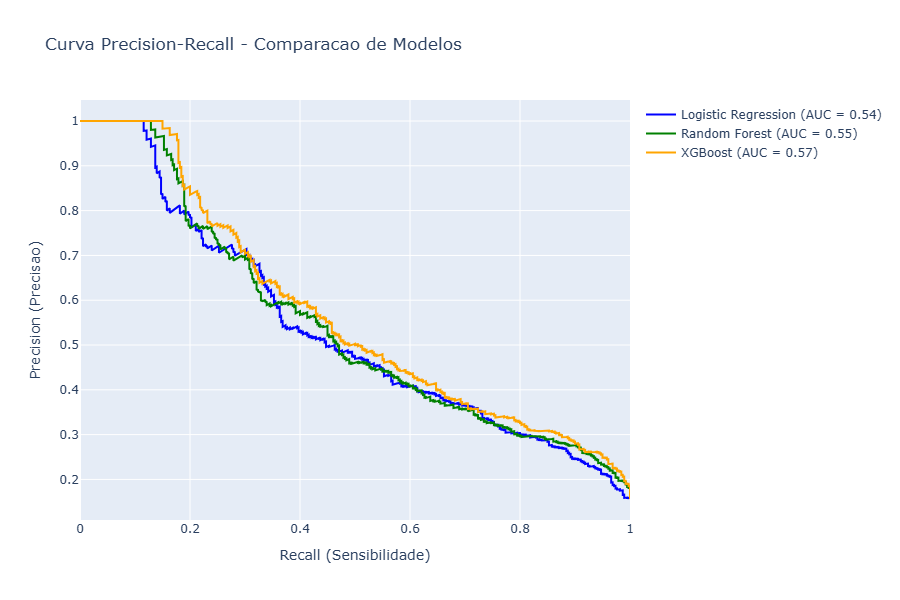

In [27]:
# Calcula Precision e Recall para cada modelo
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

# Calcula AUC da curva Precision-Recall
pr_auc_lr = auc(recall_lr, precision_lr)
pr_auc_rf = auc(recall_rf, precision_rf)
pr_auc_xgb = auc(recall_xgb, precision_xgb)

# Cria a figura Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recall_lr, y=precision_lr,
    mode='lines',
    name=f'Logistic Regression (AUC = {pr_auc_lr:.2f})',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=recall_rf, y=precision_rf,
    mode='lines',
    name=f'Random Forest (AUC = {pr_auc_rf:.2f})',
    line=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=recall_xgb, y=precision_xgb,
    mode='lines',
    name=f'XGBoost (AUC = {pr_auc_xgb:.2f})',
    line=dict(color='orange')
))

# Layout
fig.update_layout(
    title='Curva Precision-Recall - Comparação de Modelos',
    xaxis_title='Recall (Sensibilidade)',
    yaxis_title='Precision (Precisão)',
    width=900,
    height=600
)

fig.show()


### 5.3 Curva de Calibração dos Modelos
Vou verificar a calibração dos modelos para avaliar se as probabilidades previstas correspondem à frequência real observada no conjunto de teste. A linha tracejada vermelha representa o modelo idealmente calibrado.


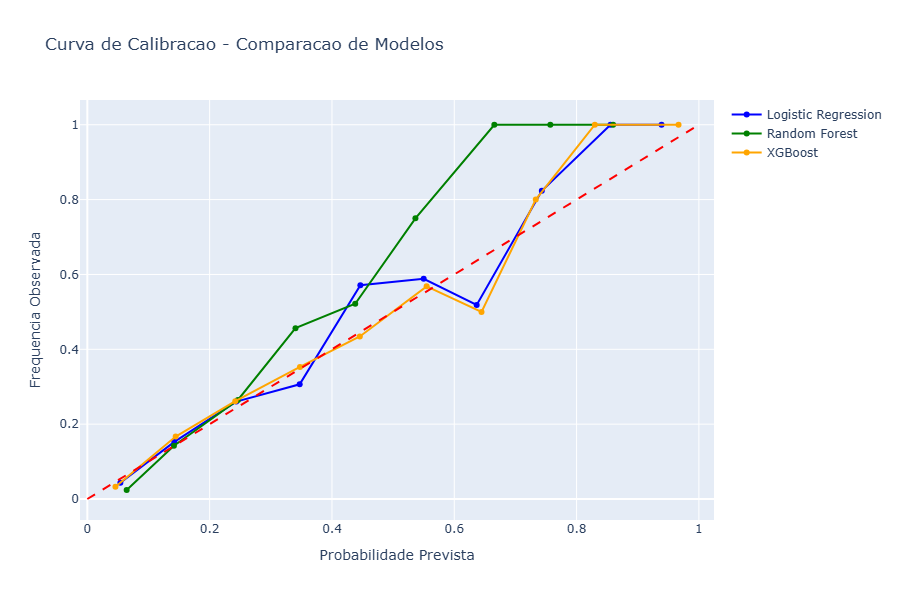

In [28]:
# Obtenção dos parametros para a curva de calibração
prob_true_lr, prob_pred_lr = calibration_curve(y_test, y_prob_lr, n_bins=10, strategy='uniform')
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=10, strategy='uniform')
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_prob_xgb, n_bins=10, strategy='uniform')

# Cria a figura Plotly
fig = go.Figure()

# Logistic Regression
fig.add_trace(go.Scatter(
    x=prob_pred_lr, y=prob_true_lr,
    mode='lines+markers',
    name='Logistic Regression',
    line=dict(color='blue')
))

# Random Forest
fig.add_trace(go.Scatter(
    x=prob_pred_rf, y=prob_true_rf,
    mode='lines+markers',
    name='Random Forest',
    line=dict(color='green')
))

# XGBoost
fig.add_trace(go.Scatter(
    x=prob_pred_xgb, y=prob_true_xgb,
    mode='lines+markers',
    name='XGBoost',
    line=dict(color='orange')
))

# Linha de referência (modelo perfeitamente calibrado)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='red', dash='dash'),
    showlegend=False
))

# Layout
fig.update_layout(
    title='Curva de Calibração - Comparação de Modelos',
    xaxis_title='Probabilidade Prevista',
    yaxis_title='Frequência Observada',
    width=900,
    height=600
)

fig.show()


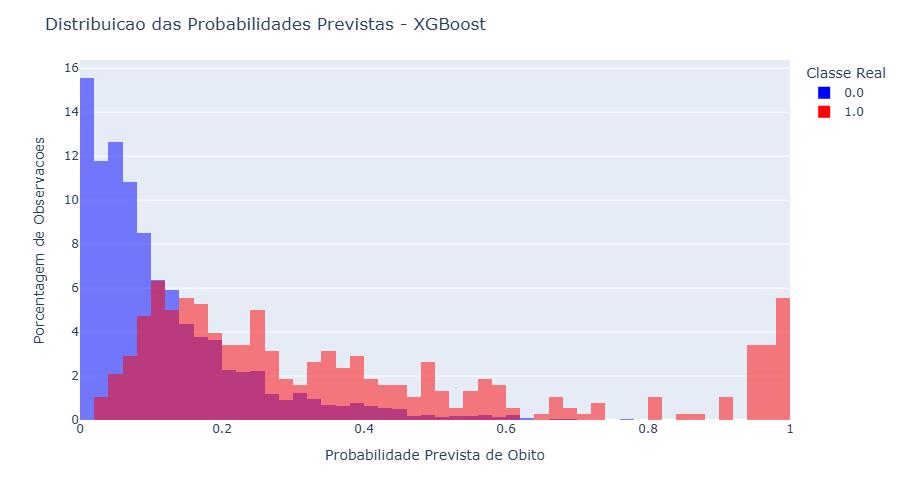

In [29]:
# Distribuição de Probabilidades - XGBoost
df_pred = pd.DataFrame({
    "probabilidade": y_prob_xgb,
    "classe_real": y_test
})

fig = px.histogram(
    df_pred,
    x="probabilidade",
    color="classe_real",
    nbins=50,
    barmode="overlay",
    histnorm="percent",  # normaliza para comparar porcentagens
    color_discrete_map={0: "blue", 1: "red"}
)

fig.update_layout(
    title="Distribuição das Probabilidades Previstas - XGBoost",
    xaxis_title="Probabilidade Prevista de Óbito",
    yaxis_title="Porcentagem de Observações",
    legend_title="Classe Real",
    width=900,
    height=500
)

fig.show()


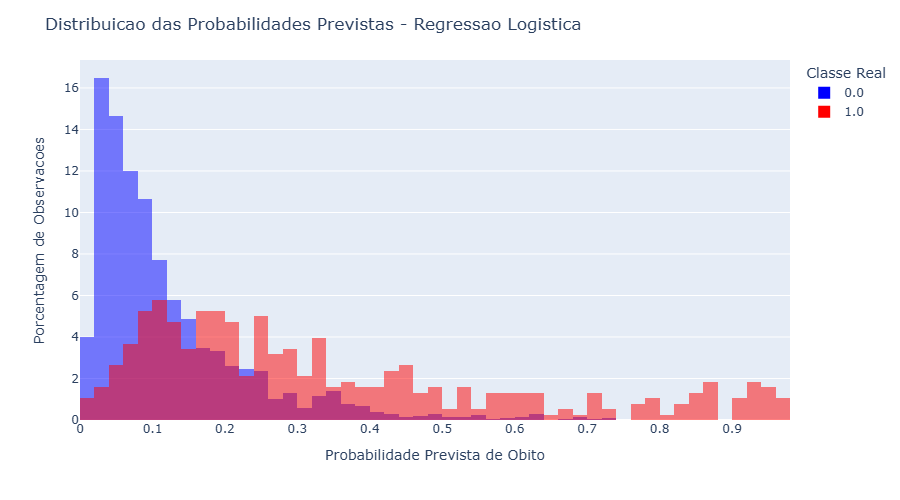

In [30]:
# Distribuição de Probabilidades - Regressão Logística
df_pred_lr = pd.DataFrame({
    "probabilidade": y_prob_lr,
    "classe_real": y_test
})

fig_lr = px.histogram(
    df_pred_lr,
    x="probabilidade",
    color="classe_real",
    nbins=50,
    barmode="overlay",
    histnorm="percent",
    color_discrete_map={0: "blue", 1: "red"}
)

fig_lr.update_layout(
    title="Distribuição das Probabilidades Previstas - Regressão Logística",
    xaxis_title="Probabilidade Prevista de Óbito",
    yaxis_title="Porcentagem de Observações",
    legend_title="Classe Real",
    width=900,
    height=500
)

fig_lr.show()


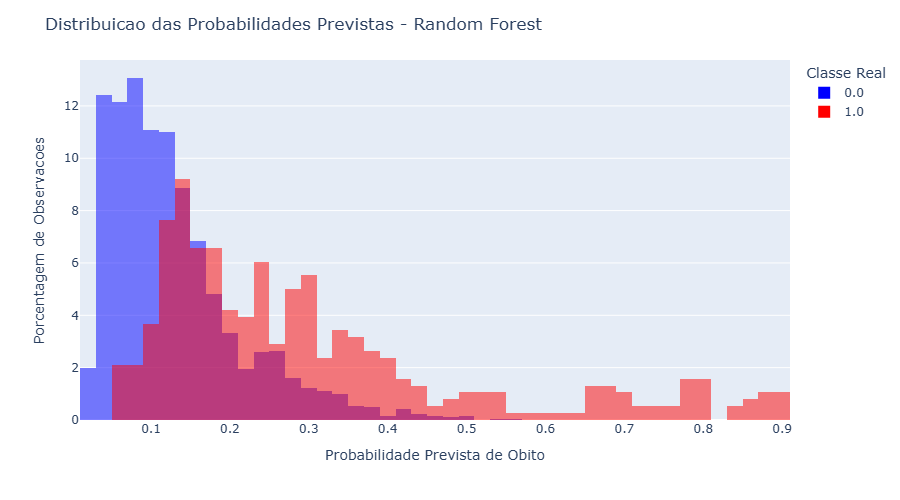

In [31]:
# Distribuição de Probabilidades - Random Forest
df_pred_rf = pd.DataFrame({
    "probabilidade": y_prob_rf,
    "classe_real": y_test
})

fig_rf = px.histogram(
    df_pred_rf,
    x="probabilidade",
    color="classe_real",
    nbins=50,
    barmode="overlay",
    histnorm="percent",
    color_discrete_map={0: "blue", 1: "red"}
)

fig_rf.update_layout(
    title="Distribuição das Probabilidades Previstas - Random Forest",
    xaxis_title="Probabilidade Prevista de Óbito",
    yaxis_title="Porcentagem de Observações",
    legend_title="Classe Real",
    width=900,
    height=500
)

fig_rf.show()


### 5.4 Avaliando as Previsões Finais de Cada Modelo (Threshold 0.5)

Vou rodar a previsão final de todos os modelos utilizando o ponto de corte padrão da estatística (0.5), para comparar os três de forma justa na mesma base.


Resultados Regressão Logística:
               precision    recall  f1-score   support

Não Óbito (0)       0.87      0.99      0.93      2051
    Óbito (1)       0.74      0.22      0.34       380

     accuracy                           0.87      2431
    macro avg       0.81      0.60      0.63      2431
 weighted avg       0.85      0.87      0.83      2431



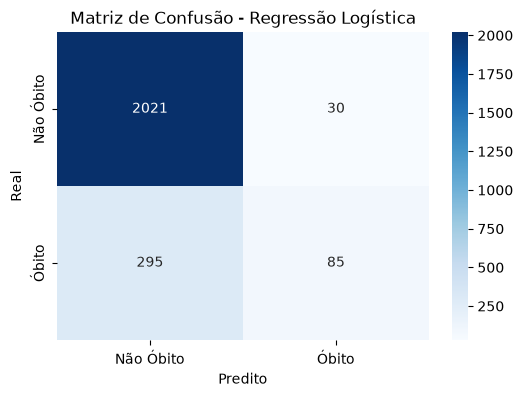

In [32]:
# Previsão Final - Regressão Logística (Threshold padrão 0.5)
pred_lr = (y_prob_lr >= 0.5).astype(int)

print("Resultados Regressão Logística:")
print(classification_report(y_test, pred_lr, target_names=['Não Óbito (0)', 'Óbito (1)']))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Óbito', 'Óbito'], yticklabels=['Não Óbito', 'Óbito'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()


Resultados Random Forest:
               precision    recall  f1-score   support

Não Óbito (0)       0.86      1.00      0.93      2051
    Óbito (1)       0.94      0.16      0.27       380

     accuracy                           0.87      2431
    macro avg       0.90      0.58      0.60      2431
 weighted avg       0.88      0.87      0.82      2431



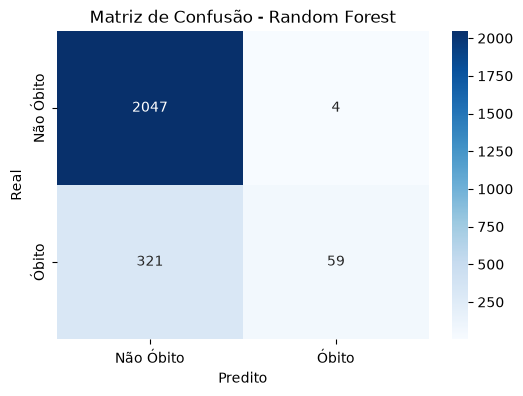

In [33]:
# Previsão Final - Random Forest (Threshold padrão 0.5)
pred_rf = (y_prob_rf >= 0.5).astype(int)

print("Resultados Random Forest:")
print(classification_report(y_test, pred_rf, target_names=['Não Óbito (0)', 'Óbito (1)']))
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Óbito', 'Óbito'], yticklabels=['Não Óbito', 'Óbito'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')
plt.show()


Resultados XGBoost (0.5):
               precision    recall  f1-score   support

Não Óbito (0)       0.88      0.99      0.93      2051
    Óbito (1)       0.77      0.25      0.38       380

     accuracy                           0.87      2431
    macro avg       0.82      0.62      0.65      2431
 weighted avg       0.86      0.87      0.84      2431



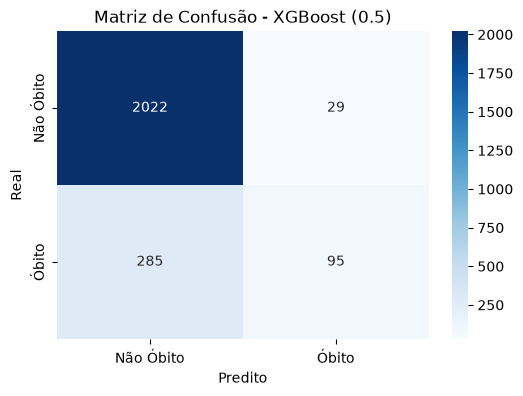

In [34]:
# Previsão Final - XGBoost (Threshold padrão 0.5)
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

print("Resultados XGBoost (0.5):")
print(classification_report(y_test, y_pred_xgb, target_names=['Não Óbito (0)', 'Óbito (1)']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Óbito', 'Óbito'], yticklabels=['Não Óbito', 'Óbito'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost (0.5)')
plt.show()


### 5.5 Escolhendo e Ajustando o Modelo Final para a Saúde (Threshold 0.3)

O XGBoost teve a melhor performance de separação. Mas para mim, que estou desenhando um modelo para área da saúde, não adianta usar o corte padrão de `50%`. 

Se o modelo acusa `30%` ou `40%` de chance de um idoso ir a óbito, eu prefiro gerar um alarme falso e acionar o médico preventivamente do que errar por omissão e perder o paciente. Então, vou forçar o modelo vencedor (XGBoost) a operar com um limite de alerta baixo (Threshold = 0.3) e analisar a **Matriz de Confusão** definitiva.


Resultados XGBoost Final (Threshold 0.3):
               precision    recall  f1-score   support

Não Óbito (0)       0.90      0.92      0.91      2051
    Óbito (1)       0.52      0.46      0.49       380

     accuracy                           0.85      2431
    macro avg       0.71      0.69      0.70      2431
 weighted avg       0.84      0.85      0.85      2431



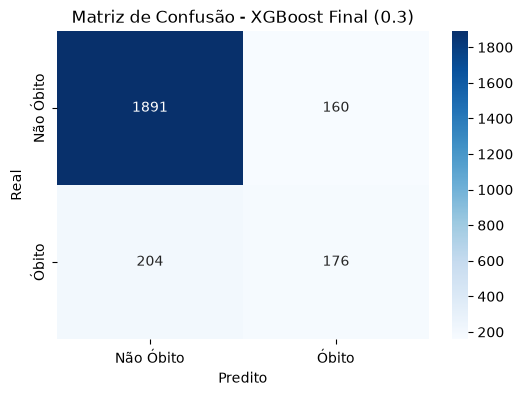

In [35]:
# Forçando o ponto de corte do XGBoost para 0.3
pred_final = (y_prob_xgb >= 0.3).astype(int)

print("Resultados XGBoost Final (Threshold 0.3):")
print(classification_report(y_test, pred_final, target_names=['Não Óbito (0)', 'Óbito (1)']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, pred_final), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Óbito', 'Óbito'], yticklabels=['Não Óbito', 'Óbito'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - XGBoost Final (0.3)')
plt.show()


## 6. Interpretabilidade do Modelo com SHAP

Nesta etapa, utilizamos o SHAP (TreeExplainer) para calcular a contribuição de cada variável do modelo na predição do risco de óbito dos pacientes da base de teste.

In [36]:
import shap

# Calculo do SHAP utilizando diretamente os nomes das variaveis da tabela
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer(X_test)

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 6.1 Visão Global: Gráfico Beeswarm

O gráfico Beeswarm sintetiza o impacto e a direção de cada variável no modelo:
* **Eixo Vertical:** Variáveis ordenadas da maior importância (topo) para a menor;
* **Eixo Horizontal:** Valor SHAP. Valores à direita (> 0) aumentam o risco previsto de óbito; à esquerda (< 0), diminuem o risco;
* **Cores:** Vermelho representa valores altos da variável e azul representa valores baixos.

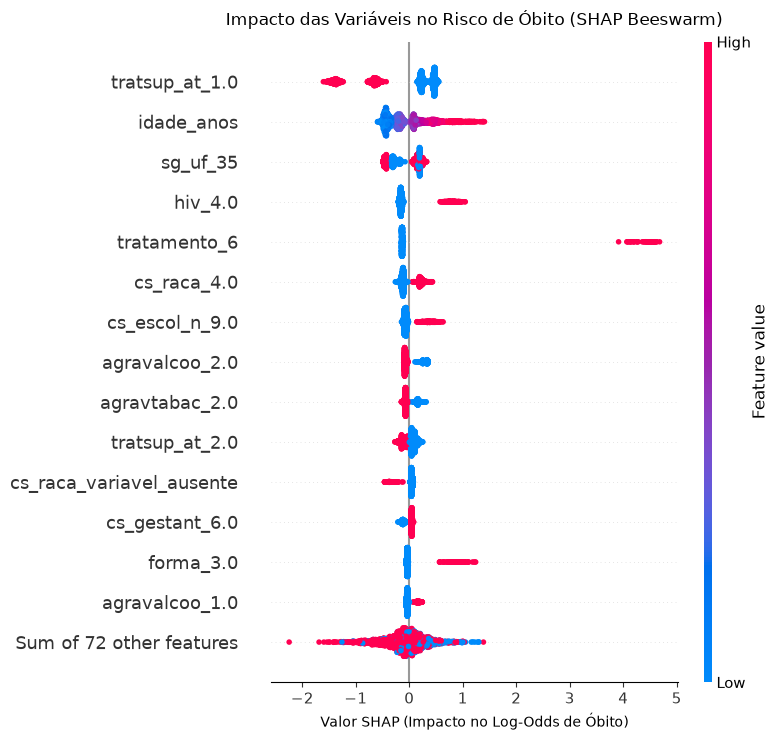

In [37]:
plt.figure(figsize=(10, 6.5))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Impacto das Variáveis no Risco de Óbito (SHAP Beeswarm)", fontsize=12, pad=12)
plt.xlabel("Valor SHAP (Impacto no Log-Odds de Óbito)", fontsize=10)
plt.tight_layout()
plt.show()

#### Principais Achados no Beeswarm:
1. **Tratamento Diretamente Observado (`tratsup_at_1.0` / `tratsup_at_2.0`):** O TDO realizado (`tratsup_at_1.0 = 1`) tem forte efeito protetor à esquerda, enquanto a ausência de TDO aumenta o risco.
2. **Idade (`idade_anos`):** Preditor contínuo de maior impacto. Idades avançadas (pontos vermelhos à direita) elevam a probabilidade de óbito.
3. **Notificação Pós-Óbito (`tratamento_6`):** Como os casos notificados post-mortem foram incluídos nesta versão da coorte, a variável surge como um dos preditores de maior impacto positivo no risco de óbito, corroborando o forte sinal emitido por essa condição no SINAN.
4. **Sorologia HIV (`hiv_4.0`):** A ausência de testagem de HIV associa-se a maior risco predito de mortalidade.
5. **Estado de Notificação (`sg_uf_35`):** Notificações do estado de São Paulo apresentam peso relevante na discriminação de desfecho.
6. **Comorbidades e Hábitos (`agravalcoo_2.0`, `agravtabac_2.0`):** Histórico de etilismo e tabagismo agregam risco, enquanto a ausência atua como fator de proteção relativa.


### 6.2 Ranking Médio de Importância (Bar Plot)

O gráfico de barras calcula a média absoluta dos valores SHAP (E[|SHAP|]), fornecendo o ranking direto da importância global das variáveis.

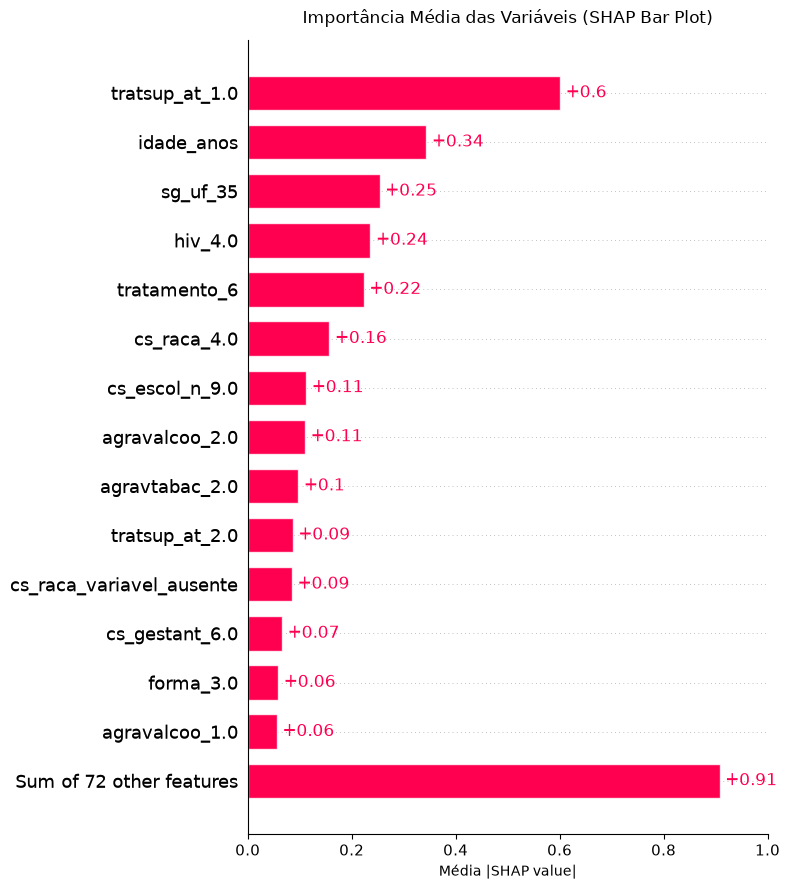

In [38]:
plt.figure(figsize=(9, 6))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Importância Média das Variáveis (SHAP Bar Plot)", fontsize=12, pad=12)
plt.xlabel("Média |SHAP value|", fontsize=10)
plt.tight_layout()
plt.show()

### 6.3 Auditoria de Casos Clínicos Individuais (Waterfall Plots)

O gráfico waterfall decompõe o cálculo de probabilidade para pacientes individuais a partir do valor base da população.

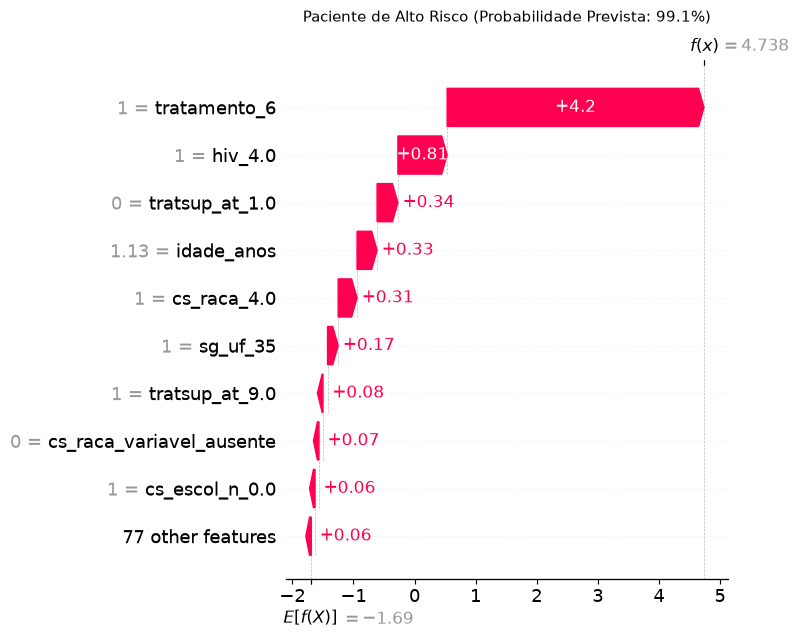

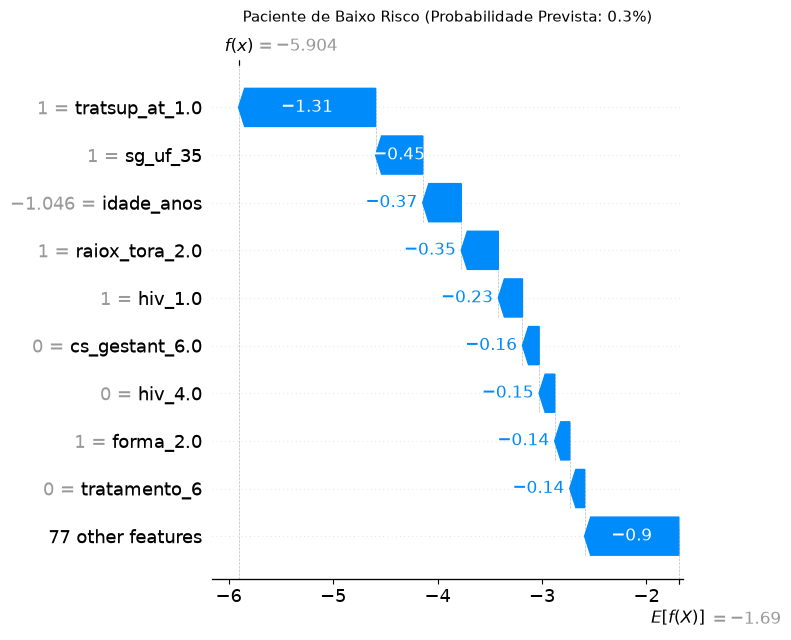

In [39]:
idx_alto = int(np.argmax(y_prob_xgb))
idx_baixo = int(np.argmin(y_prob_xgb))

# Paciente de alto risco
plt.figure(figsize=(9, 5.5))
shap.plots.waterfall(shap_values[idx_alto], max_display=10, show=False)
plt.title(f"Paciente de Alto Risco (Probabilidade Prevista: {y_prob_xgb[idx_alto]:.1%})", fontsize=11, pad=12)
plt.tight_layout()
plt.show()

# Paciente de baixo risco
plt.figure(figsize=(9, 5.5))
shap.plots.waterfall(shap_values[idx_baixo], max_display=10, show=False)
plt.title(f"Paciente de Baixo Risco (Probabilidade Prevista: {y_prob_xgb[idx_baixo]:.1%})", fontsize=11, pad=12)
plt.tight_layout()
plt.show()

### 6.4 Conclusão e Recomendações

1. **Apoio à Decisão Clínica e Vigilância:** A explicabilidade local pelo SHAP permite que o profissional de saúde confira os fatores determinantes do escore gerado pelo algoritmo.
2. **Impacto do Pós-Óbito no SINAN:** A retenção de casos com `TRATAMENTO == 6` eleva a discriminação global (AUC-ROC alcançando 0.84), refletindo a identificação assertiva dos casos que chegam ao sistema via SVO/IML.
3. **Priorização na Atenção Primária:** Pacientes no estrato de alerta (>= 30%) devem ter acompanhamento domiciliar prioritário do Agente Comunitário de Saúde e consultas médicas frequentes.
4. **Reforço ao TDO:** A magnitude do efeito protetor do TDO confirma que assegurar o tratamento supervisionado é a intervenção de maior impacto para reduzir a letalidade em idosos com tuberculose.
